In [1]:
# 01.09.2026 - 20260901d.ipynb: ILE ISTOTNOSCI ZOSTAJE PO POPRAWNEJ STATYSTYCE.
#
# Jeden watek: trzy niezalezne defekty rachunku istotnosci, kazdy zidentyfikowany
# dzis, kazdy dzialajacy w te sama strone (zawyzanie sigma). Wszystkie liczone na
# JUZ POLICZONYCH plikach - zaden nowy skan po t0.
#
#  (1) BLOKOWOSC ZNAKOW. Test binomialny w cosmoseismic_stat zaklada, ze ~665
#      koszy to ~665 niezaleznych porownan. Diagnostyka z 20260901c.ipynb
#      pokazala, ze znak skladnika A zmienia sie 172 razy zamiast oczekiwanych
#      332, czyli uklada sie w bloki o sredniej dlugosci ~3,9 binu. Liczymy
#      efektywna liczbe niezaleznych probek i przeliczamy istotnosc.
#  (2) BRAK OBCIECIA KARY. Kara Bonferroniego n*p jest prawdopodobienstwem tylko
#      dopoki nie przekroczy 1; poprawna postac to min(1, n*p). Przepis artykulu
#      (i nasza wierna implementacja z 31.08) tego nie obcina, wiec slaba era
#      aktywnie zjada wynik pozostalych, a lancuch jung1 konczy sie "p-wartoscia"
#      wieksza od jedynki.
#  (3) ILOCZYN P-WARTOSCI NIE JEST P-WARTOSCIA. Artykul mnozy cztery ukarane
#      p-wartosci i czyta iloczyn wprost jako p. Iloczyn k niezaleznych zmiennych
#      jednostajnych nie ma rozkladu jednostajnego; poprawne zlozenie to metoda
#      Fishera (-2*suma ln p ~ chi2 o 2k stopniach swobody).
#
# WEJSCIE: results/section4_penalized_chain_per_era.csv (20260901b.ipynb),
# results/section4_network_minima.csv (31.08), results/finetune_*.csv (26.08),
# dane CR i katalog USGS (tylko do punktu 1, 55 okien).
import os
import sys

import numpy as np
import pandas as pd
from scipy.stats import binom, chi2, norm

RESULTS_DIR = "../results"
DATA_DIR = "../data"
MOSC_PATH = f"{DATA_DIR}/mosc_data.csv"
OULU_PATH = f"{DATA_DIR}/oulu_5min_data.csv"
EXTENDED_DIR = f"{DATA_DIR}/csv_data_stations_extended"
FULL6H_DIR = f"{DATA_DIR}/csv_data_stations_full6h"
USGS_EXTENDED_PATH = f"{DATA_DIR}/usgs_data/usgs_m4_1965_2025.csv"

P_DAYS, D_DAYS, M_THRESHOLD, DT_DAYS = 3350, 5, 4.0, 15
BURNING_START = pd.Timestamp("2005-03-30")


def load_mosc():
    df = pd.read_csv(MOSC_PATH)
    df["datetime"] = pd.to_datetime(df["datetime"])
    return df.set_index("datetime").sort_index()["value"]


def load_oulu():
    df = pd.read_csv(OULU_PATH)
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    df = df.dropna(subset=["datetime"])
    return df.set_index("datetime").sort_index()["value"].resample("6h").mean()


def load_station(station):
    ext = os.path.join(EXTENDED_DIR, f"{station.lower()}_extended_6h.csv")
    full = os.path.join(FULL6H_DIR, f"{station.lower()}_full_6h.csv")
    df = pd.read_csv(ext if os.path.exists(ext) else full)
    df["datetime"] = pd.to_datetime(df["datetime"])
    return df.set_index("datetime").sort_index()["value"]


def load_cr(station):
    if station == "mosc":
        return load_mosc()
    if station == "oulu":
        return load_oulu()
    return load_station(station)


def load_eq(min_mag=M_THRESHOLD):
    df = pd.read_csv(USGS_EXTENDED_PATH, usecols=["time", "mag"])
    df["time"] = pd.to_datetime(df["time"], utc=True).dt.tz_localize(None)
    df = df[df["mag"] >= min_mag]
    return df.set_index("time")["mag"].sort_index()


def binuj_okno(cr, eq, t0, P_days=P_DAYS, d_days=D_DAYS, dt_days=DT_DAYS):
    # identycznie jak 20260901c.ipynb (i jak cosmoseismic_stat z 20260826d)
    N = int(P_days // d_days)
    edges = pd.date_range(t0, periods=N + 1, freq=pd.Timedelta(days=d_days))
    eq_edges = edges + pd.Timedelta(days=dt_days)
    cr_cats = pd.cut(cr.index, edges, right=False)
    cr_vals = cr.groupby(cr_cats, observed=False).mean().reindex(cr_cats.categories).to_numpy()
    w = eq[(eq.index >= eq_edges[0]) & (eq.index < eq_edges[-1])]
    eq_cats = pd.cut(w.index, eq_edges, right=False)
    sm = w.groupby(eq_cats, observed=False).sum().reindex(eq_cats.categories, fill_value=0.0).to_numpy()
    return dict(nCR_i=cr_vals[1:], nCR_im1=cr_vals[:-1], Sm=sm[1:])


eq = load_eq()
print(f"EQ M>={M_THRESHOLD}: {len(eq)} zdarzen, {eq.index.min().date()} .. {eq.index.max().date()}")
minima = pd.read_csv(f"{RESULTS_DIR}/section4_network_minima.csv", parse_dates=["t0_h5"])
minima = minima[minima["matched_h5"]].copy()
print(f"Minimow do sprawdzenia: {len(minima)}")


EQ M>=4.0: 507919 zdarzen, 1965-01-01 .. 2025-01-31
Minimow do sprawdzenia: 55


In [2]:
# KROK 1a: funkcje do efektywnej liczby niezaleznych probek.
#
# Ciag, ktory faktycznie wchodzi do testu binomialnego, to ciag ZNAKOW iloczynu
# c_i = A_i * B_i. Test zaklada, ze te znaki sa niezalezne. Mierzymy, na ile sa,
# dwoma niezaleznymi sposobami - jesli dadza podobna odpowiedz, mozna jej ufac:
#
#  (a) LICZBA SERII. Seria to maksymalny blok jednakowych znakow. Dla ciagu
#      niezaleznego srednia dlugosc serii wynosi 2, wiec serii jest ~n/2. Jesli
#      obserwujemy R serii, to efektywna liczba niezaleznych probek jest rzedu
#      R (kazdy blok wnosi mniej wiecej jedna informacje, nie tyle ile ma binow).
#      Estymator prosty i przejrzysty, ale zgrubny.
#  (b) CZAS AUTOKORELACJI tau = 1 + 2*suma rho_k po dodatnich rho_k. To
#      standardowa poprawka na autokorelacje: wariancja sumy n skorelowanych
#      zmiennych rosnie tau-krotnie, wiec n_eff = n / tau.
#
# Nastepnie przeliczamy istotnosc przy zachowanej PROPORCJI N+/n, ale przy
# zmniejszonej liczbie probek. z = 2*(p_hat - 0.5)*sqrt(n_eff).
def skladniki_A_B(bins):
    Sm, nCR_i, nCR_im1 = bins["Sm"], bins["nCR_i"], bins["nCR_im1"]
    abs_dCR = np.abs(nCR_i - nCR_im1)
    A = Sm / np.nanmedian(Sm) - 1
    B = abs_dCR / np.nanmedian(abs_dCR) - 1
    valid = ((A != 0) & (B != 0) & (nCR_i > 0) & (nCR_im1 > 0) & (Sm > 0)
             & ~np.isnan(A) & ~np.isnan(B))
    return A, B, valid


def liczba_serii(znaki):
    return int(1 + (np.diff(znaki) != 0).sum())


def czas_autokorelacji(znaki, max_lag=200):
    x = znaki.astype(float)
    x = x - x.mean()
    war = float(np.dot(x, x) / len(x))
    if war <= 0:
        return 1.0
    tau = 1.0
    for k in range(1, min(max_lag, len(x) - 2) + 1):
        rho = float(np.dot(x[:-k], x[k:]) / (len(x) - k) / war)
        if rho <= 0:          # standardowe obciecie na pierwszym ujemnym rho
            break
        tau += 2 * rho
    return tau


def z_z_proporcji(p_hat, n_probek):
    return 2.0 * (p_hat - 0.5) * np.sqrt(n_probek)


print("Funkcje gotowe. Losowy ciag n znakow ma ~n/2 serii i tau = 1.")


Funkcje gotowe. Losowy ciag n znakow ma ~n/2 serii i tau = 1.


In [3]:
# KROK 1b: przeliczenie dla 55 minimow. Dla kazdego liczymy binowanie raz,
# wyciagamy ciag znakow c_i = sign(A_i * B_i) na waznych koszach i mierzymy
# jego blokowosc. Kolumna sigma_nominalna odtwarza to, co raportuje
# cosmoseismic_stat; sigma_serie i sigma_tau to ta sama proporcja N+/n, ale
# przy efektywnej liczbie probek.
import time

start = time.time()
wiersze = []
for st, grupa in minima.groupby("station"):
    cr = load_cr(st)
    for _, r in grupa.iterrows():
        bins = binuj_okno(cr, eq, r["t0_h5"])
        A, B, valid = skladniki_A_B(bins)
        znaki = np.sign((A * B)[valid])
        n = len(znaki)
        Np = int((znaki > 0).sum())
        p_hat = Np / n
        R = liczba_serii(znaki)
        tau = czas_autokorelacji(znaki)
        wiersze.append(dict(
            station=st, era=int(r["era"]), t0=r["t0_h5"], n_binow=n, Np=Np,
            p_hat=p_hat, serie=R, srednia_dlugosc_serii=n / R, tau=tau,
            n_eff_serie=R, n_eff_tau=n / tau,
            neglog10_PPDF_nominalne=r["neglog10_PPDF_h5"],
            z_nominalne=abs(z_z_proporcji(p_hat, n)),
            z_serie=abs(z_z_proporcji(p_hat, R)),
            z_tau=abs(z_z_proporcji(p_hat, n / tau)),
        ))
    del cr

blokowosc = pd.DataFrame(wiersze).sort_values(["station", "era"])
blokowosc.to_csv(f"{RESULTS_DIR}/blokowosc_znakow_minima.csv", index=False)
print(f"Zapisano {RESULTS_DIR}/blokowosc_znakow_minima.csv, {len(blokowosc)} wierszy, "
      f"{time.time() - start:.0f} s")
print()
print("Podsumowanie po wszystkich 55 minimach (mediany):")
for k in ["n_binow", "serie", "srednia_dlugosc_serii", "tau", "n_eff_serie", "n_eff_tau",
          "z_nominalne", "z_serie", "z_tau"]:
    print(f"  {k:24s} {blokowosc[k].median():10.2f}")
print()
print("Stosunek istotnosci po poprawce do nominalnej (mediana):")
print(f"  wg liczby serii: {(blokowosc['z_serie'] / blokowosc['z_nominalne']).median():.3f}")
print(f"  wg czasu autokorelacji: {(blokowosc['z_tau'] / blokowosc['z_nominalne']).median():.3f}")


Zapisano ../results/blokowosc_znakow_minima.csv, 55 wierszy, 4 s

Podsumowanie po wszystkich 55 minimach (mediany):
  n_binow                      667.00
  serie                        297.00
  srednia_dlugosc_serii          2.19
  tau                            1.18
  n_eff_serie                  297.00
  n_eff_tau                    553.28
  z_nominalne                    5.48
  z_serie                        3.75
  z_tau                          4.98

Stosunek istotnosci po poprawce do nominalnej (mediana):
  wg liczby serii: 0.676
  wg czasu autokorelacji: 0.920


Zapisano ../results/blokowosc_znakow_minima.png


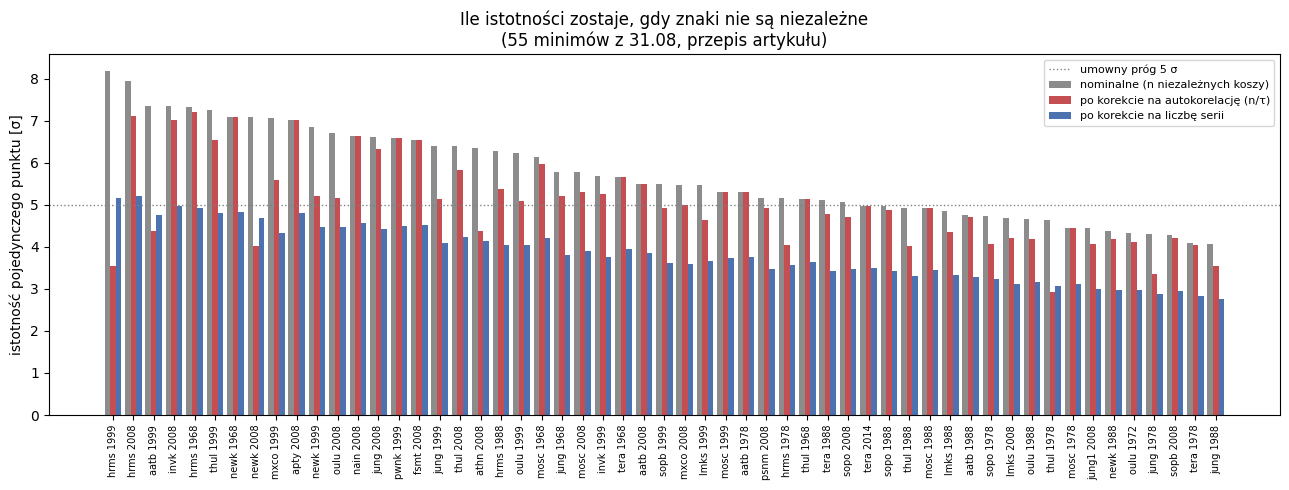

In [4]:
# Wykres 1 (jedno kodowanie: wysokosc slupka): istotnosc nominalna kontra po
# uwzglednieniu blokowosci znakow, minimum po minimum, posortowane malejaco.
import matplotlib.pyplot as plt

b = blokowosc.sort_values("z_nominalne", ascending=False).reset_index(drop=True)
x = np.arange(len(b))
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - 0.27, b["z_nominalne"], 0.27, label="nominalne (n niezależnych koszy)", color="#8C8C8C")
ax.bar(x, b["z_tau"], 0.27, label="po korekcie na autokorelację (n/τ)", color="#C44E52")
ax.bar(x + 0.27, b["z_serie"], 0.27, label="po korekcie na liczbę serii", color="#4C72B0")
ax.axhline(5, color="gray", ls=":", lw=1, label="umowny próg 5 σ")
ax.set_xticks(x)
ax.set_xticklabels([f"{r.station} {r.era}" for r in b.itertuples()], rotation=90, fontsize=7)
ax.set_ylabel("istotność pojedynczego punktu [σ]")
ax.set_title("Ile istotności zostaje, gdy znaki nie są niezależne\n"
             "(55 minimów z 31.08, przepis artykułu)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/blokowosc_znakow_minima.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/blokowosc_znakow_minima.png")


In [5]:
# KROK 2: obciecie kary do min(1, n*p) i KROK 3: zlozenie Fishera.
# Liczone na rozbiciu per era z 20260901b.ipynb, wiec dokladnie na tych samych
# lancuchach, ktore daly liczby z 31.08.
per_era = pd.read_csv(f"{RESULTS_DIR}/section4_penalized_chain_per_era.csv")
uzyte = per_era[per_era["status"] == "uzyty"].copy()
uzyte["czynnik_obciety"] = uzyte["czynnik"].clip(upper=1.0)

def zloz(grupa):
    czynniki = grupa["czynnik"].to_numpy()
    obciete = grupa["czynnik_obciety"].to_numpy()
    k = len(czynniki)
    il_nom = float(np.prod(czynniki))
    il_obc = float(np.prod(obciete))
    out = dict(n_er=k, iloczyn_nominalny=il_nom, iloczyn_obciety=il_obc)
    out["sigma_nominalna"] = float(norm.isf(il_nom)) if 0 < il_nom < 1 else np.nan
    out["sigma_obcieta"] = float(norm.isf(il_obc)) if 0 < il_obc < 1 else np.nan
    # zlozenie Fishera: -2*suma ln(p) ma rozklad chi2 o 2k stopniach swobody
    if 0 < il_obc < 1:
        p_fisher = float(chi2.sf(-2 * np.log(il_obc), 2 * k))
        out["p_fisher"] = p_fisher
        out["sigma_fisher"] = float(norm.isf(p_fisher)) if p_fisher > 0 else np.inf
    else:
        out["p_fisher"], out["sigma_fisher"] = np.nan, np.nan
    return pd.Series(out)


kaskada = (uzyte.groupby(["metoda", "wariant", "station"]).apply(zloz, include_groups=False)
           .reset_index())
kaskada.to_csv(f"{RESULTS_DIR}/istotnosc_kaskada_poprawek.csv", index=False)
print(f"Zapisano {RESULTS_DIR}/istotnosc_kaskada_poprawek.csv, {len(kaskada)} wierszy")
print()
glowna = kaskada[(kaskada.metoda == "stala") & (kaskada.wariant == "a_z_wykluczeniem")]
print("Metoda stalego punktu, wariant z wykluczeniem burning sample:")
print(glowna[["station", "n_er", "sigma_nominalna", "sigma_obcieta", "sigma_fisher"]]
      .sort_values("sigma_nominalna", ascending=False).round(2).to_string(index=False))
print()
print("Ile er mialo czynnik > 1 (czyli bylo obcinanych):")
print(f"  {(uzyte['czynnik'] > 1).sum()} z {len(uzyte)} wszystkich czynnikow we wszystkich lancuchach")


Zapisano ../results/istotnosc_kaskada_poprawek.csv, 67 wierszy

Metoda stalego punktu, wariant z wykluczeniem burning sample:
station  n_er  sigma_nominalna  sigma_obcieta  sigma_fisher
   hrms   4.0             7.40           7.40          6.16
   aatb   3.0             6.45           6.45          5.52
   newk   4.0             4.41           4.41          2.88
   thul   4.0             4.18           4.18          2.62
   mosc   4.0             4.12           4.51          2.99
   jung   4.0             4.07           4.07          2.49
   mxco   1.0             3.60           3.60          3.60
   oulu   3.0             2.34           2.34          1.00
   tera   4.0             1.92           3.41          1.73
   lmks   2.0             1.69           2.58          1.86
   sopo   4.0             1.15           2.72          0.92
   sopb   1.0             0.43           0.43          0.43
  jung1   2.0              NaN            NaN           NaN

Ile er mialo czynnik > 1 (czyli b

In [6]:
# Ten sam rachunek dla liczb SAMEGO ARTYKULU - kontrola, ze poprawki dotycza
# przepisu, a nie tylko naszej jego implementacji. Pary (PPDF, faktor) sa
# wypisane wprost w sekcji 4 artykulu (str. 5).
art = [(3.34e-8, 3430), (3.0e-6, 2682), (3.58e-5, 1952), (2.92e-6, 1207)]
czynniki_art = np.array([p * n for p, n in art])
il_art = float(np.prod(czynniki_art))
il_art_obc = float(np.prod(np.clip(czynniki_art, None, 1.0)))
p_f_art = float(chi2.sf(-2 * np.log(il_art_obc), 2 * len(art)))

print("Liczby artykulu (sekcja 4):")
for (p, n), c in zip(art, czynniki_art):
    print(f"  PPDF={p:.2e} x n={n:5d} = {c:.3e}   {'(>1, byloby obcinane)' if c > 1 else ''}")
print(f"  iloczyn = {il_art:.3e}  ->  sigma = {norm.isf(il_art):.2f}  "
      f"(artykul podaje 2.3e-10 / 6.3)")
print(f"  po obcieciu min(1, n*p): iloczyn = {il_art_obc:.3e} -> sigma = {norm.isf(il_art_obc):.2f}")
print(f"  po zlozeniu Fishera (k={len(art)}): p = {p_f_art:.3e} -> sigma = {norm.isf(p_f_art):.2f}")
print()
print("UWAGA: powyzsze dotyczy WYLACZNIE sposobu zlozenia czterech minimow.")
print("Korekta na blokowosc znakow (Krok 1) dziala niezaleznie i dodatkowo, ale")
print("nie da sie jej policzyc dla liczb artykulu - wymaga dostepu do ich")
print("ciagow znakow, ktorych artykul nie publikuje.")


Liczby artykulu (sekcja 4):
  PPDF=3.34e-08 x n= 3430 = 1.146e-04   
  PPDF=3.00e-06 x n= 2682 = 8.046e-03   
  PPDF=3.58e-05 x n= 1952 = 6.988e-02   
  PPDF=2.92e-06 x n= 1207 = 3.524e-03   
  iloczyn = 2.270e-10  ->  sigma = 6.23  (artykul podaje 2.3e-10 / 6.3)
  po obcieciu min(1, n*p): iloczyn = 2.270e-10 -> sigma = 6.23
  po zlozeniu Fishera (k=4): p = 4.756e-07 -> sigma = 4.90

UWAGA: powyzsze dotyczy WYLACZNIE sposobu zlozenia czterech minimow.
Korekta na blokowosc znakow (Krok 1) dziala niezaleznie i dodatkowo, ale
nie da sie jej policzyc dla liczb artykulu - wymaga dostepu do ich
ciagow znakow, ktorych artykul nie publikuje.


Zapisano ../results/istotnosc_kaskada_poprawek.png


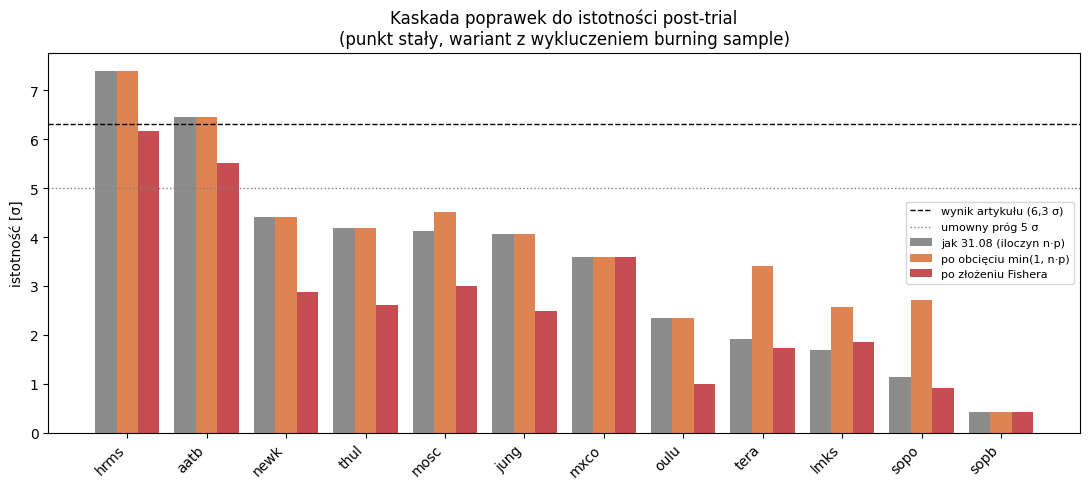

In [7]:
# Wykres 2 (jedno kodowanie: wysokosc slupka): kaskada poprawek dla stacji,
# ktore w ogole maja wynik. Pokazuje, ile zostaje po kazdym kolejnym kroku.
g = glowna.dropna(subset=["sigma_nominalna"]).sort_values("sigma_nominalna", ascending=False)
x = np.arange(len(g))
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - 0.27, g["sigma_nominalna"], 0.27, label="jak 31.08 (iloczyn n·p)", color="#8C8C8C")
ax.bar(x, g["sigma_obcieta"], 0.27, label="po obcięciu min(1, n·p)", color="#DD8452")
ax.bar(x + 0.27, g["sigma_fisher"], 0.27, label="po złożeniu Fishera", color="#C44E52")
ax.axhline(6.3, color="black", ls="--", lw=1, label="wynik artykułu (6,3 σ)")
ax.axhline(5.0, color="gray", ls=":", lw=1, label="umowny próg 5 σ")
ax.set_xticks(x)
ax.set_xticklabels(g["station"], rotation=45, ha="right")
ax.set_ylabel("istotność [σ]")
ax.set_title("Kaskada poprawek do istotności post-trial\n"
             "(punkt stały, wariant z wykluczeniem burning sample)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/istotnosc_kaskada_poprawek.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/istotnosc_kaskada_poprawek.png")


In [8]:
# Podsumowanie: pelna kaskada dla dwoch stacji, ktore 31.08 przekroczyly 6.3
# sigma. Kazdy wiersz to jedna niezalezna poprawka, wszystkie sie skladaja.
print("=" * 72)
print("KASKADA POPRAWEK - PODSUMOWANIE")
print("=" * 72)
for st in ["hrms", "aatb"]:
    w = glowna[glowna.station == st]
    if not len(w):
        continue
    w = w.iloc[0]
    bl = blokowosc[blokowosc.station == st]
    wsp_tau = (bl["z_tau"] / bl["z_nominalne"]).median()
    print()
    print(f"{st.upper()} (metoda stalego punktu, wariant z wykluczeniem burning sample)")
    print(f"  1. jak raportowano 31.08                        {w['sigma_nominalna']:6.2f} sigma")
    print(f"  2. + obciecie kary do min(1, n*p)               {w['sigma_obcieta']:6.2f} sigma")
    print(f"  3. + poprawne zlozenie er (Fisher, k={int(w['n_er'])})         "
          f"{w['sigma_fisher']:6.2f} sigma")
    print(f"  4. + blokowosc znakow: mediana z_tau/z_nom = {wsp_tau:.2f} dla tej stacji")
    print(f"     (poprawka mnozaca, dziala na kazde PPDF W SRODKU lancucha,")
    print(f"      wiec nie da sie jej po prostu domnozyc do sigma z punktu 3 -")
    print(f"      wymaga przeliczenia lancucha od poczatku, patrz punkty otwarte)")
print()
print("Poprawka na k_eff (wybor najlepszej stacji z sieci, 20260901a.ipynb) jest")
print("piata i w praktyce pomijalna (~0.1 sigma), bo k_eff wynosi ~2.")


KASKADA POPRAWEK - PODSUMOWANIE

HRMS (metoda stalego punktu, wariant z wykluczeniem burning sample)
  1. jak raportowano 31.08                          7.40 sigma
  2. + obciecie kary do min(1, n*p)                 7.40 sigma
  3. + poprawne zlozenie er (Fisher, k=4)           6.16 sigma
  4. + blokowosc znakow: mediana z_tau/z_nom = 0.86 dla tej stacji
     (poprawka mnozaca, dziala na kazde PPDF W SRODKU lancucha,
      wiec nie da sie jej po prostu domnozyc do sigma z punktu 3 -
      wymaga przeliczenia lancucha od poczatku, patrz punkty otwarte)

AATB (metoda stalego punktu, wariant z wykluczeniem burning sample)
  1. jak raportowano 31.08                          6.45 sigma
  2. + obciecie kary do min(1, n*p)                 6.45 sigma
  3. + poprawne zlozenie er (Fisher, k=3)           5.52 sigma
  4. + blokowosc znakow: mediana z_tau/z_nom = 1.00 dla tej stacji
     (poprawka mnozaca, dziala na kazde PPDF W SRODKU lancucha,
      wiec nie da sie jej po prostu domnozyc do sigma